Analyzing result CSVs across different groups to detect any significant trends.

In [7]:
import sys
import csv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import optimal_alpha_csv as opt
from constants import EVALUATED_COSTS_DIR

fname = EVALUATED_COSTS_DIR + "\pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA1511_ABA_Salt001_M248_10_C_10aba.csv"

homog_opt_info, heterog_opt_info, alpha_diff, sq_orthog_dist_diff = opt.extract_optimal_dist_vals(fname, len(EVALUATED_COSTS_DIR))
print(f"Homogenous Optimal Info: {homog_opt_info} | Heterogeneous Optimal Info: {heterog_opt_info} | Difference in Alpha: {alpha_diff} | Difference in Sq. Ortog. Distance: {sq_orthog_dist_diff}")

def extract_difference_values(arbor_folder):
    folder = Path(arbor_folder)

    alpha_diffs = []
    sq_orthog_dist_diffs = []
    for i, arbor_file in enumerate(folder.glob("*.csv")):
        if i >= 1000: # to prevent errors with encountering an incomplete CSV
            break
        
        homog_opt_info, heterog_opt_info, alpha_diff, sq_orthog_dist_diff = opt.extract_optimal_dist_vals(arbor_file, len(EVALUATED_COSTS_DIR))
        alpha_diffs.append(alpha_diff)
        sq_orthog_dist_diffs.append(sq_orthog_dist_diff)

    return alpha_diffs, sq_orthog_dist_diffs


        


Homogenous Optimal Info: ['pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA1511_ABA_Salt001_M248_10_C_10aba.csv', ' homogeneous', ' 0.000000', ' 1.000000', ' 0.914192'] | Heterogeneous Optimal Info: ['pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA1511_ABA_Salt001_M248_10_C_10aba.csv', ' heterogeneous', ' 0.000000', ' 1.000000', ' 0.914192'] | Difference in Alpha: 0.0 | Difference in Sq. Ortog. Distance: 0.0


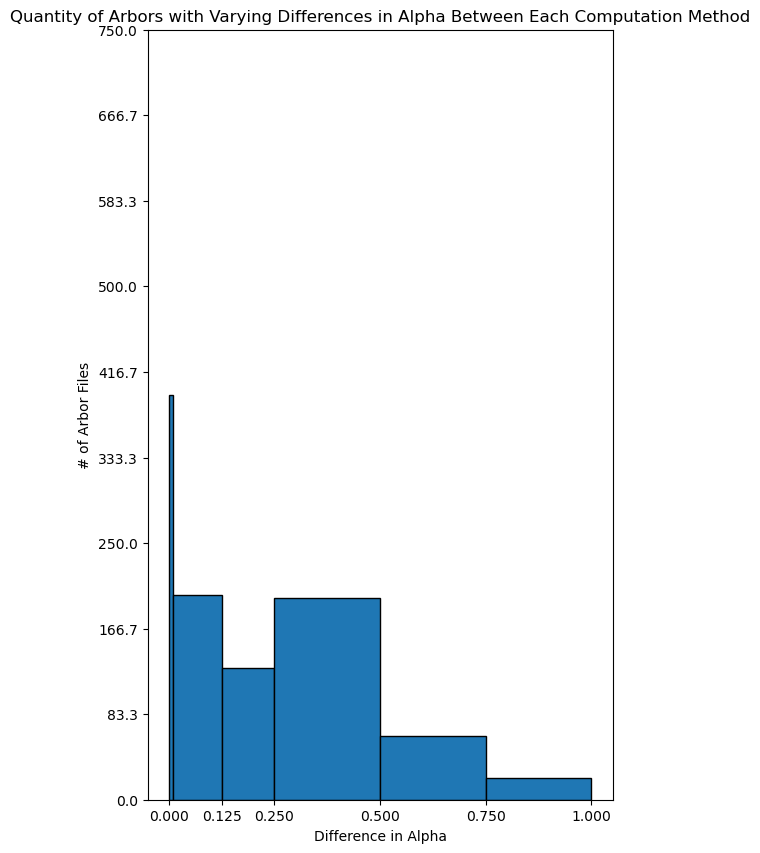

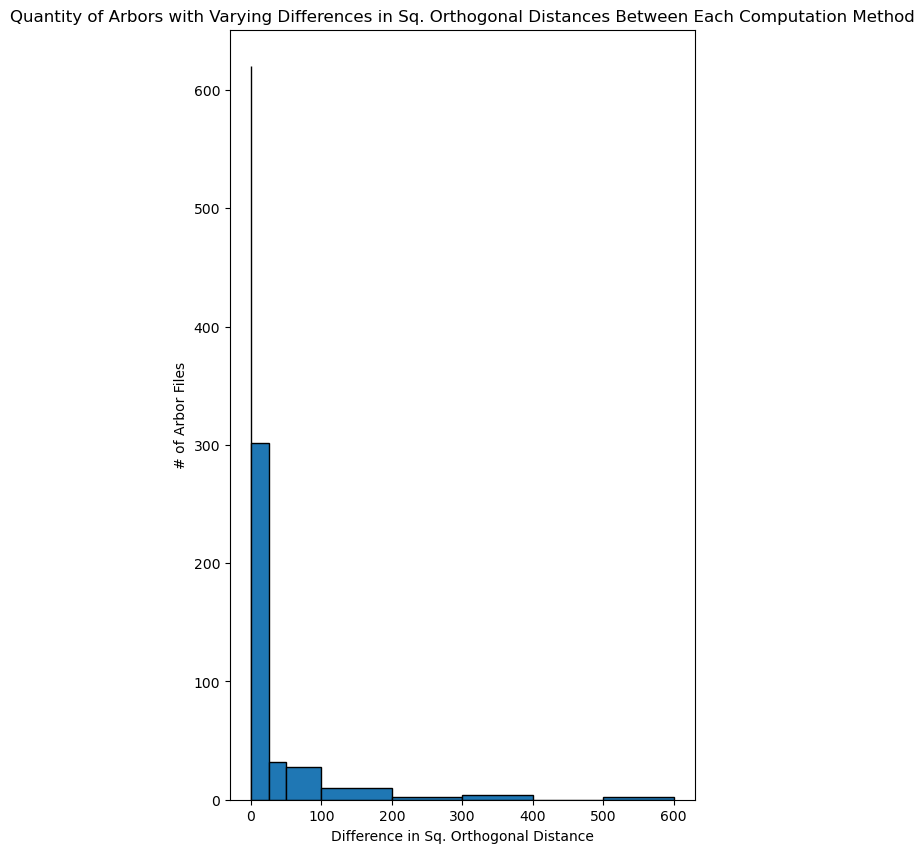

In [ ]:
# Creating a histogram that categorizes values based on what range the difference in alpha (between each computation method) falls under

alpha_diffs, sq_orthog_dist_diffs = extract_difference_values(EVALUATED_COSTS_DIR)
plt.figure(figsize=(6, 10))
plt.hist(alpha_diffs, bins=[0, .01, .125, 0.25, 0.5, 0.75, 1.0], edgecolor='black')

plt.yticks(np.linspace(0, 750, 10))
plt.xticks([0, 0.125, 0.25, 0.5, 0.75, 1.0])
plt.xlabel("Difference in Alpha")
plt.ylabel("# of Arbor Files")
plt.title("Quantity of Arbors with Varying Differences in Alpha Between Each Computation Method")
plt.show()

plt.figure(figsize=(6, 10))
plt.hist(sq_orthog_dist_diffs, bins=[0, .01, 25, 50, 100, 200, 300, 400, 500, 600], edgecolor='black')
plt.xticks([0, .01, 25, 50, 100, 200, 300, 400, 500, 600])
plt.xlabel("Difference in Sq. Orthogonal Distance")
plt.ylabel("# of Arbor Files")
plt.title("Quantity of Arbors with Varying Differences in Sq. Orthogonal Distances Between Each Computation Method")
plt.show()